/var/folders/yp/078pyxw11mq6g7sd_2ty18z80000gn/T/ipykernel_2564/4086900646.py:1: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit




DEUTSCH-JOZSA - RANDOMIZED BALANCED ORACLE

Number of input qubits : 4
Number of possible inputs : 16
Number of random tests : 5

The generator randomly selects exactly half of all input combinations to have f(x)=1.
Therefore every generated function is balanced.


RANDOM TEST 1

Number of f(x)=0 values : 8
Number of f(x)=1 values : 8
Balanced property       : VERIFIED

RANDOM BALANCED TRUTH TABLE
----------------------------------------------------------------------
Input          f(x)      
----------------------------------------------------------------------
0000           0
0001           1
0010           1
0011           1
0100           1
0101           0
0110           0
0111           0
1000           1
1001           0
1010           0
1011           0
1100           1
1101           0
1110           1
1111           1

QUANTUM CIRCUIT
----------------------------------------------------------------------
     ┌───┐     ┌─────────────────┐┌───┐
q_0: ┤ H ├─────┤0            

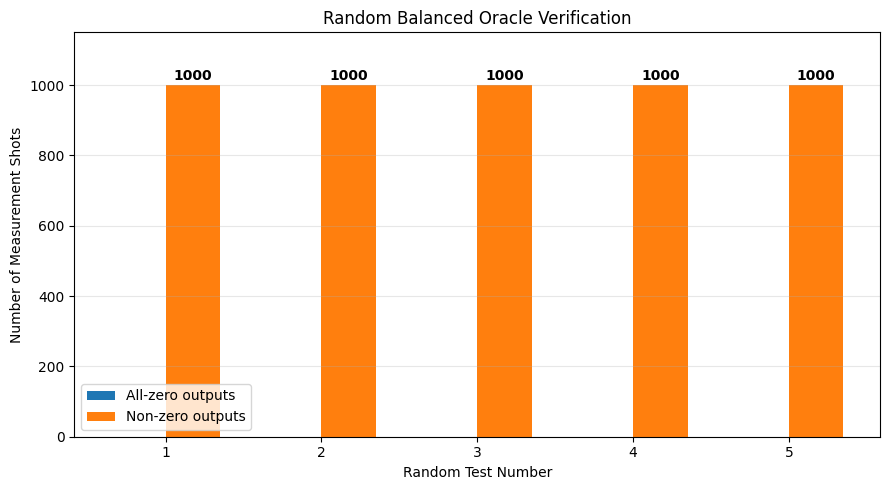

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# DEUTSCH-JOZSA - RANDOM BALANCED ORACLE GENERATOR
# =========================================================

SHOTS = 1000
N = 4
NUMBER_OF_TESTS = 5
SEED = 42


# =========================================================
# CREATE RANDOM BALANCED TRUTH TABLE
# =========================================================

def generate_balanced_truth_table(n, rng):

    total_inputs = 2 ** n

    # Create exactly half 0s and half 1s
    truth_table = np.array(
        [0] * (total_inputs // 2)
        + [1] * (total_inputs // 2)
    )

    # Randomly shuffle the function values
    rng.shuffle(truth_table)

    return truth_table


# =========================================================
# CREATE ORACLE FROM TRUTH TABLE
# =========================================================

def create_balanced_oracle(n, truth_table):

    oracle = QuantumCircuit(
        n + 1,
        name="RandomBalanced"
    )

    # For every input x where f(x) = 1,
    # flip the ancilla qubit.

    for x in range(2 ** n):

        if truth_table[x] == 1:

            # Convert zero bits to one.
            # This allows MCX to recognize the
            # required input pattern.

            for qubit in range(n):

                if ((x >> qubit) & 1) == 0:

                    oracle.x(qubit)

            # Multi-controlled X operation
            oracle.mcx(
                list(range(n)),
                n
            )

            # Restore the input qubits

            for qubit in range(n):

                if ((x >> qubit) & 1) == 0:

                    oracle.x(qubit)

    return oracle.to_gate()


# =========================================================
# BUILD DEUTSCH-JOZSA CIRCUIT
# =========================================================

def build_deutsch_jozsa_circuit(
    n,
    oracle
):

    qc = QuantumCircuit(
        n + 1
    )

    # -----------------------------------------------------
    # STEP 1: SUPERPOSITION
    # -----------------------------------------------------

    for qubit in range(n):

        qc.h(qubit)

    # -----------------------------------------------------
    # STEP 2: PREPARE ANCILLA |1>
    # -----------------------------------------------------

    qc.x(n)

    # -----------------------------------------------------
    # STEP 3: PREPARE ANCILLA |->
    # -----------------------------------------------------

    qc.h(n)

    # -----------------------------------------------------
    # STEP 4: ONE ORACLE QUERY
    # -----------------------------------------------------

    qc.append(
        oracle,
        list(range(n + 1))
    )

    # -----------------------------------------------------
    # STEP 5: FINAL HADAMARD
    # -----------------------------------------------------

    for qubit in range(n):

        qc.h(qubit)

    return qc


# =========================================================
# EXTRACT INPUT REGISTER PROBABILITIES
# =========================================================

def get_input_probabilities(
    statevector,
    n
):

    full_probabilities = (
        statevector.probabilities()
    )

    input_probabilities = np.zeros(
        2 ** n
    )

    # Combine probabilities corresponding
    # to the two possible ancilla states.

    for index, probability in enumerate(
        full_probabilities
    ):

        input_value = index % (2 ** n)

        input_probabilities[
            input_value
        ] += probability

    # Remove tiny floating-point errors

    input_probabilities = (
        input_probabilities
        / np.sum(input_probabilities)
    )

    return input_probabilities


# =========================================================
# SIMULATE MEASUREMENTS
# =========================================================

def simulate_measurements(
    probabilities,
    shots,
    rng
):

    outcomes = np.arange(
        len(probabilities)
    )

    samples = rng.choice(
        outcomes,
        size=shots,
        p=probabilities
    )

    counts = np.bincount(
        samples,
        minlength=len(probabilities)
    )

    return counts


# =========================================================
# CLASSIFY DEUTSCH-JOZSA RESULT
# =========================================================

def classify_result(counts):

    # If every measurement is all-zero,
    # the function is constant.

    if counts[0] == np.sum(counts):

        return "CONSTANT"

    # Otherwise it is balanced.

    return "BALANCED"


# =========================================================
# DISPLAY TRUTH TABLE
# =========================================================

def display_truth_table(
    n,
    truth_table
):

    print("\nRANDOM BALANCED TRUTH TABLE")
    print("-" * 70)

    print(
        f"{'Input':<15}"
        f"{'f(x)':<10}"
    )

    print("-" * 70)

    for x in range(2 ** n):

        binary_input = format(
            x,
            f"0{n}b"
        )

        print(
            f"{binary_input:<15}"
            f"{truth_table[x]}"
        )


# =========================================================
# RUN RANDOMIZED TESTS
# =========================================================

rng = np.random.default_rng(
    SEED
)

test_numbers = []
all_zero_counts = []
non_zero_counts = []
successful_tests = 0


print("\n")
print("=" * 80)
print("DEUTSCH-JOZSA - RANDOMIZED BALANCED ORACLE")
print("=" * 80)

print(
    f"\nNumber of input qubits : {N}"
)

print(
    f"Number of possible inputs : {2 ** N}"
)

print(
    f"Number of random tests : {NUMBER_OF_TESTS}"
)

print(
    "\nThe generator randomly selects exactly half "
    "of all input combinations to have f(x)=1."
)

print(
    "Therefore every generated function is balanced."
)


# =========================================================
# MULTIPLE RANDOM TESTS
# =========================================================

for test in range(
    1,
    NUMBER_OF_TESTS + 1
):

    print("\n")
    print("=" * 80)

    print(
        f"RANDOM TEST {test}"
    )

    print("=" * 80)

    # -----------------------------------------------------
    # GENERATE RANDOM BALANCED FUNCTION
    # -----------------------------------------------------

    truth_table = generate_balanced_truth_table(
        N,
        rng
    )

    # -----------------------------------------------------
    # VERIFY BALANCED PROPERTY
    # -----------------------------------------------------

    number_of_zeros = int(
        np.sum(truth_table == 0)
    )

    number_of_ones = int(
        np.sum(truth_table == 1)
    )

    print(
        f"\nNumber of f(x)=0 values : "
        f"{number_of_zeros}"
    )

    print(
        f"Number of f(x)=1 values : "
        f"{number_of_ones}"
    )

    if (
        number_of_zeros
        == number_of_ones
        == 2 ** (N - 1)
    ):

        print(
            "Balanced property       : VERIFIED"
        )

    else:

        print(
            "Balanced property       : FAILED"
        )

    # -----------------------------------------------------
    # DISPLAY TRUTH TABLE
    # -----------------------------------------------------

    display_truth_table(
        N,
        truth_table
    )

    # -----------------------------------------------------
    # CREATE ORACLE
    # -----------------------------------------------------

    oracle = create_balanced_oracle(
        N,
        truth_table
    )

    # -----------------------------------------------------
    # BUILD DEUTSCH-JOZSA CIRCUIT
    # -----------------------------------------------------

    qc = build_deutsch_jozsa_circuit(
        N,
        oracle
    )

    # -----------------------------------------------------
    # CALCULATE STATEVECTOR
    # -----------------------------------------------------

    state = Statevector.from_instruction(
        qc
    )

    probabilities = get_input_probabilities(
        state,
        N
    )

    # -----------------------------------------------------
    # MEASURE
    # -----------------------------------------------------

    counts = simulate_measurements(
        probabilities,
        SHOTS,
        rng
    )

    # -----------------------------------------------------
    # CLASSIFICATION
    # -----------------------------------------------------

    classification = classify_result(
        counts
    )

    most_probable = int(
        np.argmax(probabilities)
    )

    output = format(
        most_probable,
        f"0{N}b"
    )

    # -----------------------------------------------------
    # STORE RESULTS
    # -----------------------------------------------------

    test_numbers.append(
        test
    )

    all_zero_counts.append(
        int(counts[0])
    )

    non_zero_counts.append(
        int(np.sum(counts[1:]))
    )

    # -----------------------------------------------------
    # DISPLAY CIRCUIT
    # -----------------------------------------------------

    print("\nQUANTUM CIRCUIT")
    print("-" * 70)

    print(
        qc.draw()
    )

    # -----------------------------------------------------
    # DISPLAY MEASUREMENT RESULTS
    # -----------------------------------------------------

    print("\nMEASUREMENT RESULTS")
    print("-" * 70)

    print(
        f"Shots                 : "
        f"{SHOTS}"
    )

    print(
        f"Most probable output  : "
        f"{output}"
    )

    print(
        f"000...0 count         : "
        f"{counts[0]}"
    )

    print(
        f"Non-zero count        : "
        f"{int(np.sum(counts[1:]))}"
    )

    print(
        f"P(000...0)            : "
        f"{counts[0] / SHOTS:.4f}"
    )

    print(
        f"P(non-zero)           : "
        f"{np.sum(counts[1:]) / SHOTS:.4f}"
    )

    print(
        f"Predicted classification : "
        f"{classification}"
    )

    print(
        "Expected classification  : "
        "BALANCED"
    )

    # -----------------------------------------------------
    # VERIFY RESULT
    # -----------------------------------------------------

    if classification == "BALANCED":

        print(
            "Verification           : "
            "CORRECT"
        )

        successful_tests += 1

    else:

        print(
            "Verification           : "
            "INCORRECT"
        )


# =========================================================
# FINAL VERIFICATION
# =========================================================

print("\n")
print("=" * 80)
print("FINAL RANDOMIZED TEST SUMMARY")
print("=" * 80)

print(
    f"\nInput qubits              : "
    f"{N}"
)

print(
    f"Total random tests        : "
    f"{NUMBER_OF_TESTS}"
)

print(
    f"Successful classifications : "
    f"{successful_tests}/{NUMBER_OF_TESTS}"
)

if successful_tests == NUMBER_OF_TESTS:

    print(
        "\nFINAL RESULT              : "
        "ALL RANDOM BALANCED FUNCTIONS "
        "CLASSIFIED CORRECTLY"
    )

else:

    print(
        "\nFINAL RESULT              : "
        "SOME TESTS FAILED"
    )


# =========================================================
# VISUALIZATION
# =========================================================

fig, ax = plt.subplots(
    figsize=(9, 5)
)

x = np.arange(
    NUMBER_OF_TESTS
)

width = 0.35

bars1 = ax.bar(
    x - width / 2,
    all_zero_counts,
    width,
    label="All-zero outputs"
)

bars2 = ax.bar(
    x + width / 2,
    non_zero_counts,
    width,
    label="Non-zero outputs"
)

ax.set_title(
    "Random Balanced Oracle Verification"
)

ax.set_xlabel(
    "Random Test Number"
)

ax.set_ylabel(
    "Number of Measurement Shots"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    test_numbers
)

ax.set_ylim(
    0,
    SHOTS * 1.15
)

for bars in [
    bars1,
    bars2
]:

    for bar in bars:

        value = bar.get_height()

        if value > 0:

            ax.text(
                bar.get_x()
                + bar.get_width() / 2,
                value + 15,
                str(int(value)),
                ha="center",
                fontweight="bold"
            )

ax.grid(
    axis="y",
    alpha=0.3
)

ax.legend()

plt.tight_layout()

plt.show()